<a href="https://colab.research.google.com/github/OnwutaKelvin/ML-notebooks/blob/main/Brain_Tumor_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

import torch

from sklearn.model_selection import train_test_split

In [ ]:
dataset_path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes")
print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-images-30-classes' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-images-30-classes


In [ ]:
print(os.listdir(dataset_path))

['Astrocytoma T2', 'Neurocytoma T1C+', 'Glioma T1', 'Schwannoma T1C+', 'Hemangiopericytoma T2', 'DATA.json', 'Meningioma T2', 'Oligodendroglioma T1C+', 'Other T1C+', 'Ependymoma T2', 'Ependymoma T1C+', 'Glioma T2', 'Meningioma T1', 'Astrocytoma T1C+', 'Astrocytoma T1', 'Ependymoma T1', 'Meningioma T1C+', 'Neurocytoma T1', 'Normal T1', 'Glioma T1C+', 'Oligodendroglioma T2', 'Schwannoma T2', 'Schwannoma T1', 'Other T1', 'Hemangiopericytoma T1C+', 'Normal T2', 'Hemangiopericytoma T1', 'Normal T1C+', 'Neurocytoma T2', 'Oligodendroglioma T1', 'Other T2']


In [ ]:
for root, dirs, files in os.walk(dataset_path):
  print(root, "=>", len(files), "files")

/kaggle/input/brain-tumor-mri-images-30-classes => 1 files
/kaggle/input/brain-tumor-mri-images-30-classes/Astrocytoma T2 => 281 files
/kaggle/input/brain-tumor-mri-images-30-classes/Neurocytoma T1C+ => 254 files
/kaggle/input/brain-tumor-mri-images-30-classes/Glioma T1 => 522 files
/kaggle/input/brain-tumor-mri-images-30-classes/Schwannoma T1C+ => 564 files
/kaggle/input/brain-tumor-mri-images-30-classes/Hemangiopericytoma T2 => 118 files
/kaggle/input/brain-tumor-mri-images-30-classes/Meningioma T2 => 458 files
/kaggle/input/brain-tumor-mri-images-30-classes/Oligodendroglioma T1C+ => 192 files
/kaggle/input/brain-tumor-mri-images-30-classes/Other T1C+ => 756 files
/kaggle/input/brain-tumor-mri-images-30-classes/Ependymoma T2 => 350 files
/kaggle/input/brain-tumor-mri-images-30-classes/Ependymoma T1C+ => 374 files
/kaggle/input/brain-tumor-mri-images-30-classes/Glioma T2 => 405 files
/kaggle/input/brain-tumor-mri-images-30-classes/Meningioma T1 => 636 files
/kaggle/input/brain-tumor-m

In [ ]:
from collections import Counter

all_image_paths = []

for root, _, files in os.walk(dataset_path):
  for file in files:
    # Only consider image files (e.g., .jpg, .jpeg)
    if file.lower().endswith(('.jpg', '.jpeg')):
      full_path = os.path.join(root, file)
      all_image_paths.append(full_path)

# Count extensions for the collected image paths
all_image_extensions = [os.path.splitext(p)[1].lower() for p in all_image_paths]
extension_counts = Counter(all_image_extensions)

print("Total image files found:", len(all_image_paths))
print("Image file extension counts:", extension_counts)

Total image files found: 11300
Image file extension counts: Counter({'.jpg': 11300})


In [ ]:
# Creating a DataFrame with image paths
df = pd.DataFrame({"image_path": all_image_paths})
display(df.head())

,image_path
0,/kaggle/input/brain-tumor-mri-images-30-classe...
1,/kaggle/input/brain-tumor-mri-images-30-classe...
2,/kaggle/input/brain-tumor-mri-images-30-classe...
3,/kaggle/input/brain-tumor-mri-images-30-classe...
4,/kaggle/input/brain-tumor-mri-images-30-classe...


In [ ]:
# Extract label from folder name using the full image path
df["label"] = df["image_path"].apply(lambda x: os.path.basename(os.path.dirname(x)))
display(df["label"].head())

,label
0,Astrocytoma T2
1,Astrocytoma T2
2,Astrocytoma T2
3,Astrocytoma T2
4,Astrocytoma T2


In [ ]:
#Data shape
print("Total Images:", df.shape[0])
print("No of Columns:", df.shape[1])

Total Images: 11300
No of Columns: 2


In [ ]:
#missing values
df.isnull().sum()

,0
image_path,0
label,0


In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#class count
class_counts = df["label"].value_counts()
print(class_counts)

label
Meningioma T1C+            977
Other T1C+                 756
Meningioma T1              636
Schwannoma T1C+            564
Glioma T1C+                549
Glioma T1                  522
Meningioma T2              458
Astrocytoma T1C+           441
Normal T1                  415
Other T1                   412
Glioma T2                  405
Astrocytoma T1             396
Normal T2                  379
Ependymoma T1C+            374
Other T2                   365
Schwannoma T1              363
Ependymoma T2              350
Ependymoma T1              313
Schwannoma T2              309
Hemangiopericytoma T1C+    307
Astrocytoma T2             281
Normal T1C+                264
Neurocytoma T1C+           254
Oligodendroglioma T1       221
Oligodendroglioma T1C+     192
Neurocytoma T1             190
Hemangiopericytoma T1      178
Neurocytoma T2             174
Oligodendroglioma T2       137
Hemangiopericytoma T2      118
Name: count, dtype: int64


In [ ]:
#No of classes
num_classes = df["label"].nunique()
print("Number of Classes:", num_classes)

Number of Classes: 30


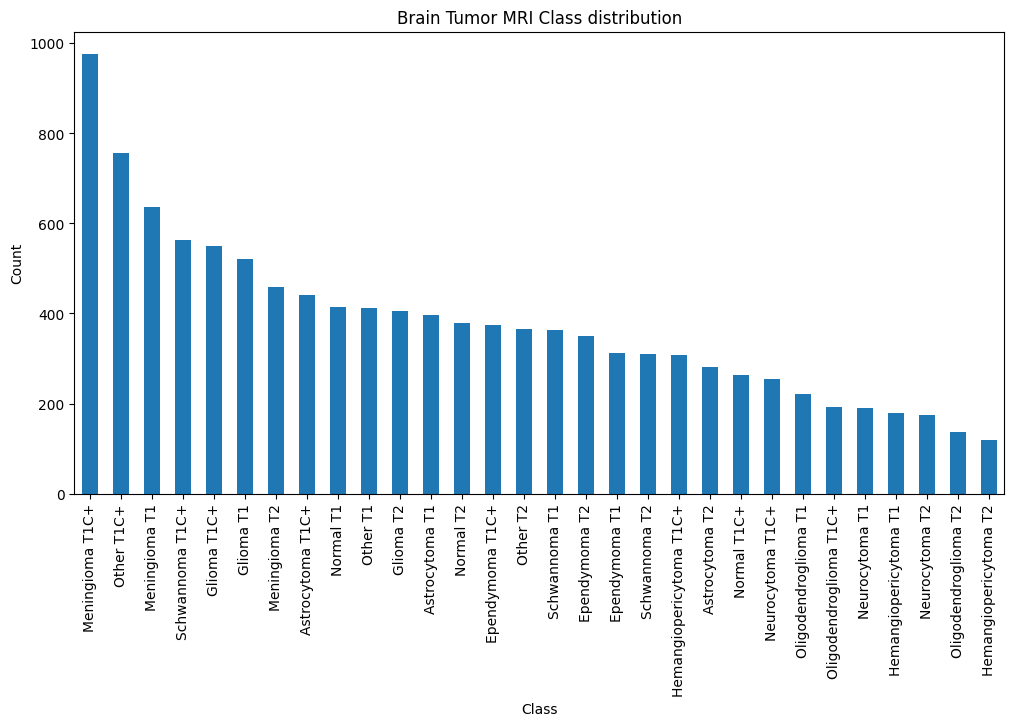

In [ ]:
#Plot distribution of classes
plt.figure(figsize=(12, 6))
class_counts.plot(kind="bar")
plt.title("Brain Tumor MRI Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [ ]:
#Extract MRI weightings
def extract_weighting(label):
  if "T1C+" in label:
    return "T1C+"
  elif "T1" in label:
    return "T1"
  elif "T2" in label:
    return "T2"
  else:
    return "Unknown"

df["weightings"] = df["label"].apply(extract_weighting)

df.head()


,image_path,label,weightings
0,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2
1,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2
2,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2
3,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2
4,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2


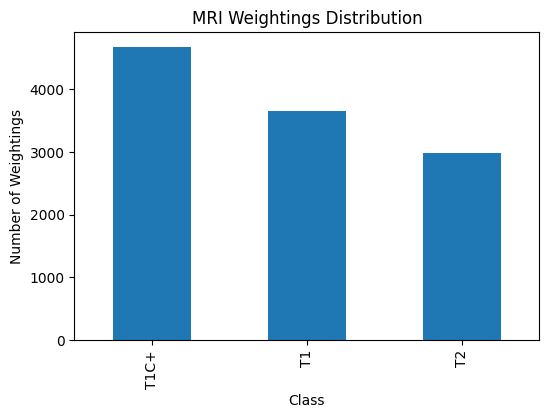

In [ ]:
#MRI weightings Distribution
df["weightings"].value_counts()

plt.figure(figsize=(6, 4))
df["weightings"].value_counts().plot(kind="bar")
plt.title("MRI Weightings Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Weightings")
plt.show()

In [ ]:
#MRI weightings Distribution
df["weightings"].value_counts()

,count
weightings,
T1C+,4678
T1,3646
T2,2976


In [ ]:
import pandas as pd

#Get Tumor Types
def extract_tumor_type(label):
  return label.replace("T1C+", "").replace("T1", "").replace("T2", "").strip()

df["tumor_type"] = df["label"].apply(extract_tumor_type)
df.head()

,image_path,label,weightings,tumor_type
0,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2,Astrocytoma
1,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2,Astrocytoma
2,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2,Astrocytoma
3,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2,Astrocytoma
4,/kaggle/input/brain-tumor-mri-images-30-classe...,Astrocytoma T2,T2,Astrocytoma


In [ ]:
#Tumor type count
df["tumor_type"].value_counts()

,count
tumor_type,
Meningioma,2071
Other,1533
Glioma,1476
Schwannoma,1236
Astrocytoma,1118
Normal,1058
Ependymoma,1037
Neurocytoma,618
Hemangiopericytoma,603


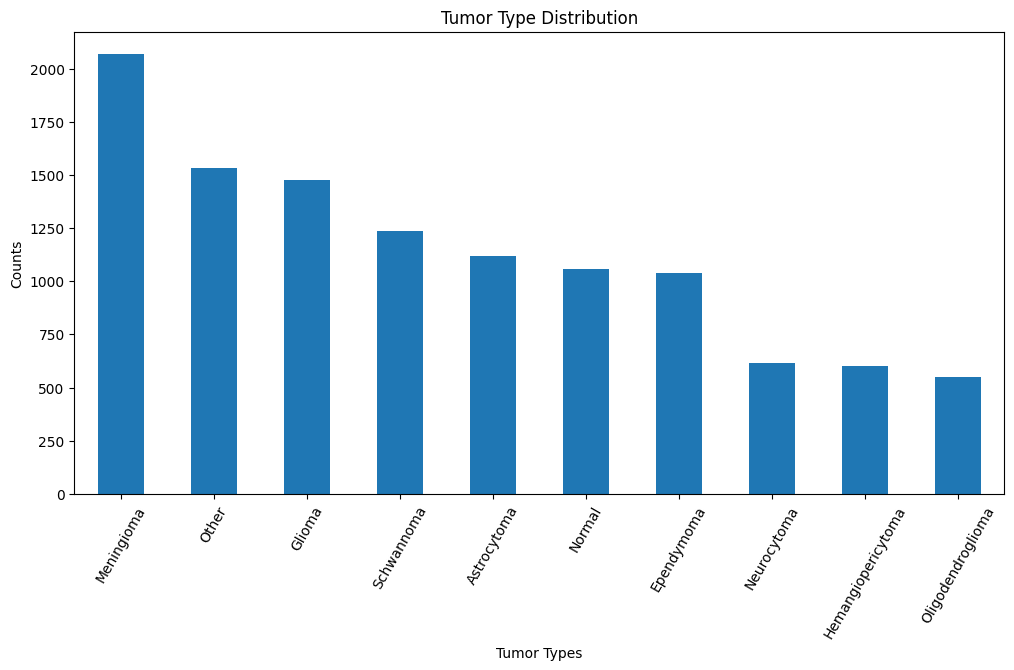

In [ ]:
#Tumor type plot distribution
plt.figure(figsize=(12, 6))
df["tumor_type"].value_counts().plot(kind="bar")
plt.title("Tumor Type Distribution")
plt.xlabel("Tumor Types")
plt.ylabel("Counts")
plt.xticks(rotation=60)
plt.show()

In [ ]:
#creating Normal vs Tumor
df["binary_label"] = df["tumor_type"].apply(lambda x: "Normal" if x == "Normal" else "Tumor")
df["binary_label"].value_counts()

,count
binary_label,
Tumor,10242
Normal,1058


In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

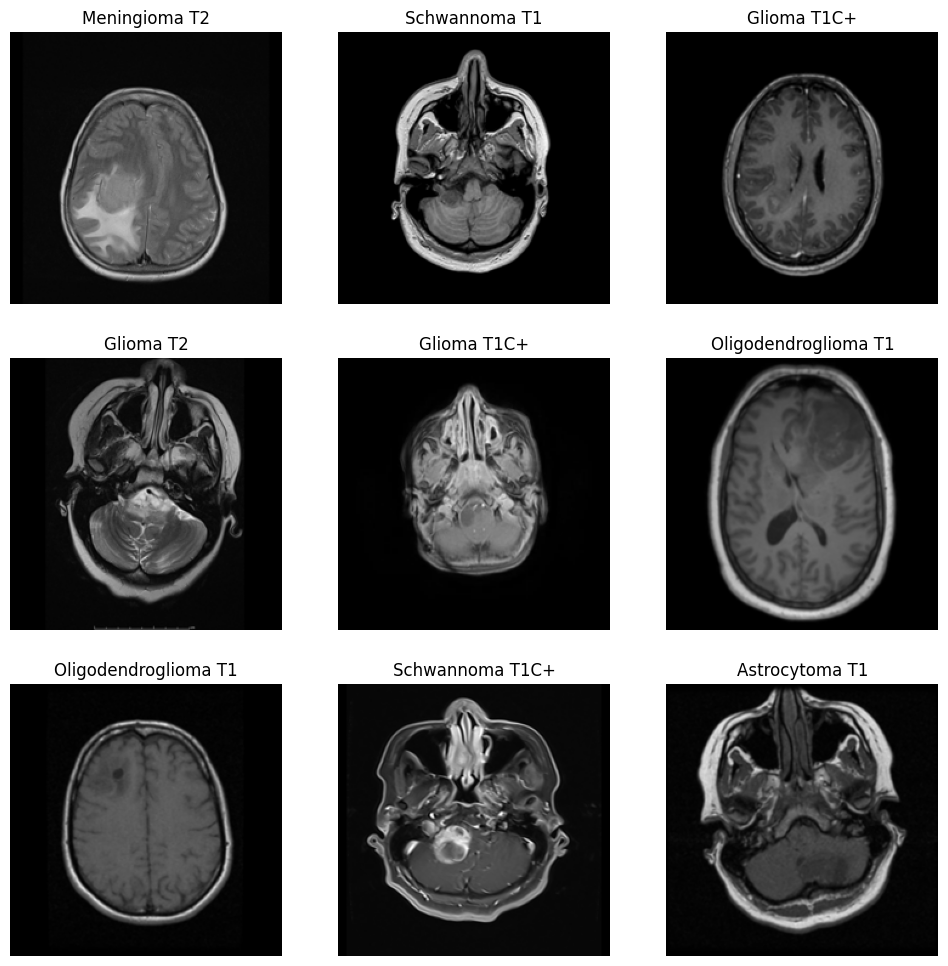

In [ ]:
from PIL import Image

#display sample images
sample_df = df.sample(min(9, len(df)), random_state=seed)

plt.figure(figsize=(12, 12))

for i, row in enumerate(sample_df.itertuples()):
  img = Image.open(row.image_path).resize((224, 224))
  plt.subplot(3, 3, i+1)
  plt.imshow(img, cmap="gray")
  plt.title(row.label)
  plt.axis("off")

plt.show()

In [ ]:
#Image size check
sizes = []

for path in df["image_path"].sample(min(50, len(df)), random_state=seed):
  img = Image.open(path)
  sizes.append(img.size)

pd.Series(sizes).value_counts().head()

,count
"(512, 512)",50


In [ ]:
print(img.mode)
print(img.size)

RGB
(512, 512)


In [ ]:
#Device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(device)

cuda


In [ ]:
from torchvision import transforms
#Data Augumentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

#Datasets differnetiation
#Dataset
train_df, test_df = train_test_split(
    df,
    train_size=0.9,
    stratify=df['label'],
    random_state=seed

)

#train and validation split
train_df, val_df = train_test_split(
    train_df,
    train_size=0.8, # 0.8 of the current train_df, which is 0.8 * 0.9 = 0.72 of the original df
    stratify=train_df['label'], # Stratify based on the label within this subset
    random_state=seed
)

print("Train Shape:", train_df.shape)
print("Val Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (8136, 5)
Val Shape: (2034, 5)
Test Shape: (1130, 5)


In [ ]:
#index the labels
unique_labels = df['label'].unique()
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for idx, label in enumerate(unique_labels)}
num_classes = len(unique_labels)

print(f"Number of classes: {num_classes}")
print("Label to index mapping:", label_to_idx)

Number of classes: 30
Label to index mapping: {'Astrocytoma T2': 0, 'Neurocytoma T1C+': 1, 'Glioma T1': 2, 'Schwannoma T1C+': 3, 'Hemangiopericytoma T2': 4, 'Meningioma T2': 5, 'Oligodendroglioma T1C+': 6, 'Other T1C+': 7, 'Ependymoma T2': 8, 'Ependymoma T1C+': 9, 'Glioma T2': 10, 'Meningioma T1': 11, 'Astrocytoma T1C+': 12, 'Astrocytoma T1': 13, 'Ependymoma T1': 14, 'Meningioma T1C+': 15, 'Neurocytoma T1': 16, 'Normal T1': 17, 'Glioma T1C+': 18, 'Oligodendroglioma T2': 19, 'Schwannoma T2': 20, 'Schwannoma T1': 21, 'Other T1': 22, 'Hemangiopericytoma T1C+': 23, 'Normal T2': 24, 'Hemangiopericytoma T1': 25, 'Normal T1C+': 26, 'Neurocytoma T2': 27, 'Oligodendroglioma T1': 28, 'Other T2': 29}


In [ ]:
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']

        image = Image.open(img_path).convert('RGB') # Ensure image is RGB

        if self.transform:
            image = self.transform(image)

        label_idx = label_to_idx[label] # Convert string label to integer
        return image, label_idx

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() # Use all available CPU cores as workers

# Instantiate datasets
train_dataset_obj = BrainTumorDataset(train_df, train_transform)
val_dataset_obj = BrainTumorDataset(val_df, test_transform)
test_dataset_obj = BrainTumorDataset(test_df, test_transform)

# Loading Datasets
train_loader = DataLoader(
    train_dataset_obj,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset_obj,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset_obj,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 255
Number of validation batches: 64
Number of test batches: 36


In [ ]:
#Building a Custom CNN
import torch.nn as nn

class BrainTumorCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.features = nn.Sequential(
        #block 1
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        #Block 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        #Block 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        # After 3 MaxPool2d layers on a 224x224 image:
        # 224 -> 112 -> 56 -> 28
        # Output channels from last conv: 128
        # So, the flattened size is 128 * 28 * 28
        nn.Linear(128 * 28 * 28, 256),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(256, num_classes) # Changed to num_classes (30) from 10
      )

  def forward(self, x):
    x = self.features(x)
    # Removed redundant 'x = x' line
    x = self.classifier(x)
    return x

In [ ]:
!pip install torchinfo
from torchinfo import summary

model = BrainTumorCNN().to(device)

# To get a model summary in PyTorch, we use torchinfo.summary
# We need to provide the input size that the model expects (e.g., batch_size, channels, height, width)
summary(model, input_size=(BATCH_SIZE, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
BrainTumorCNN                            [32, 30]                  --
├─Sequential: 1-1                        [32, 128, 28, 28]         --
│    └─Conv2d: 2-1                       [32, 32, 224, 224]        896
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        64
│    └─ReLU: 2-3                         [32, 32, 224, 224]        --
│    └─MaxPool2d: 2-4                    [32, 32, 112, 112]        --
│    └─Conv2d: 2-5                       [32, 64, 112, 112]        18,496
│    └─BatchNorm2d: 2-6                  [32, 64, 112, 112]        128
│    └─ReLU: 2-7                         [32, 64, 112, 112]        --
│    └─MaxPool2d: 2-8                    [32, 64, 56, 56]          --
│    └─Conv2d: 2-9                       [32, 128, 56, 56]         73,856
│    └─BatchNorm2d: 2-10                 [32, 128, 56, 56]         256
│    └─ReLU: 2-11                        [32, 128, 56, 56]         --
│   

In [ ]:
#Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
#Training Loop
from tqdm import tqdm
# Removed redundant import: import torch.nn as nn

epochs = 20
best_val_acc = 0

train_losses = [] # Initialize list to store training losses per epoch
val_losses = []   # Initialize list to store validation losses per epoch
train_accuracies = [] # Initialize list to store training accuracies per epoch
val_accuracies = []   # Initialize list to store validation accuracies per epoch

for epoch in range(epochs):
  model.train()

  running_loss = 0
  correct = 0
  total = 0

  loop = tqdm(train_loader, leave=True) # Set leave=True to keep the final state of the progress bar

  for images, labels in loop:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    loss = loss_fn(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item() # Accumulate batch loss

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    # Update tqdm description and postfix
    loop.set_description(f"Epoch [{epoch+1}/{epochs}] (Training)")
    loop.set_postfix(
        loss=running_loss / (loop.n + 1),
        acc=(100. * correct / total) if total > 0 else 0
    )

  # Calculate epoch-wise training metrics
  train_loss = running_loss / len(train_loader)
  train_acc = 100. * correct / total


  # VALIDATION LOOP
  model.eval()

  val_running_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    val_loop = tqdm(val_loader, leave=True) # Use a separate tqdm for validation
    for images, labels in val_loop:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = loss_fn(outputs, labels) # Calculate loss for validation

      val_running_loss += loss.item()

      _, predicted = torch.max(outputs, 1)

      val_total += labels.size(0)
      val_correct += (predicted == labels).sum().item()

      # Update tqdm description and postfix for validation
      val_loop.set_description(f"Epoch [{epoch+1}/{epochs}] (Validation)")
      val_loop.set_postfix(
          loss=val_running_loss / (val_loop.n + 1),
          acc=(100. * val_correct / val_total) if val_total > 0 else 0
      )

  # Calculate epoch-wise validation metrics
  val_loss = val_running_loss / len(val_loader)
  val_acc = 100. * val_correct / val_total

  # Store metrics
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_accuracies.append(train_acc)
  val_accuracies.append(val_acc)

  print(
      f"\nEpoch [{epoch+1}/{epochs}] | "
      f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
      f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
  )

  # Save the best model
  if val_acc > best_val_acc:
    best_val_acc = val_acc

    torch.save(
        model.state_dict(),
        "best_model.pth"
    )
    print("Best Model Saved!")


Epoch [1/20] (Validation): 100%|██████████| 64/64 [00:10<00:00,  6.30it/s, acc=8.7, loss=3.36]



Epoch [1/20] | Train Loss: 4.5054 | Train Acc: 6.61% | Val Loss: 3.3639 | Val Acc: 8.70%
Best Model Saved!


Epoch [2/20] (Validation): 100%|██████████| 64/64 [00:09<00:00,  6.92it/s, acc=8.65, loss=3.34]



Epoch [2/20] | Train Loss: 3.3523 | Train Acc: 8.59% | Val Loss: 3.3373 | Val Acc: 8.65%


Epoch [3/20] (Validation): 100%|██████████| 64/64 [00:10<00:00,  6.13it/s, acc=8.65, loss=3.31]


...


Epoch [18/20] | Train Loss: 3.0312 | Train Acc: 11.65% | Val Loss: 2.9033 | Val Acc: 12.39%
Best Model Saved!


Epoch [19/20] (Validation): 100%|██████████| 64/64 [00:09<00:00,  6.51it/s, acc=11.8, loss=2.94]



Epoch [19/20] | Train Loss: 3.0049 | Train Acc: 12.21% | Val Loss: 2.9380 | Val Acc: 11.85%


Epoch [20/20] (Validation): 100%|██████████| 64/64 [00:09<00:00,  6.76it/s, acc=13.3, loss=2.87]



Epoch [20/20] | Train Loss: 3.0080 | Train Acc: 11.91% | Val Loss: 2.8654 | Val Acc: 13.27%
Best Model Saved!


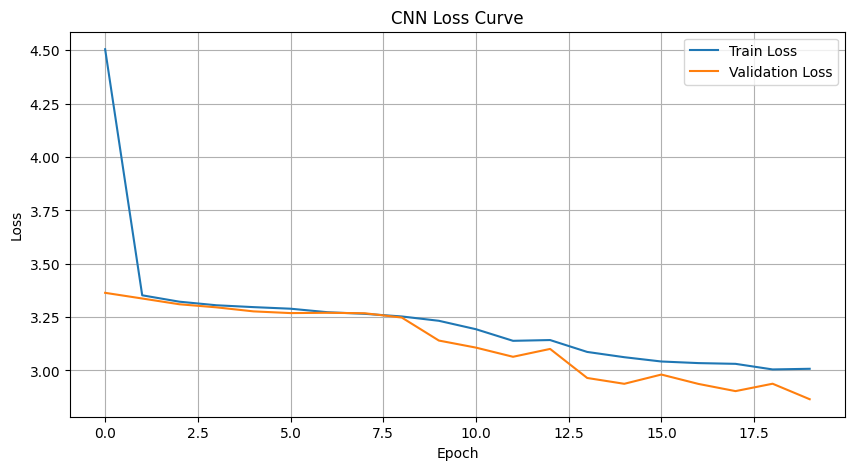

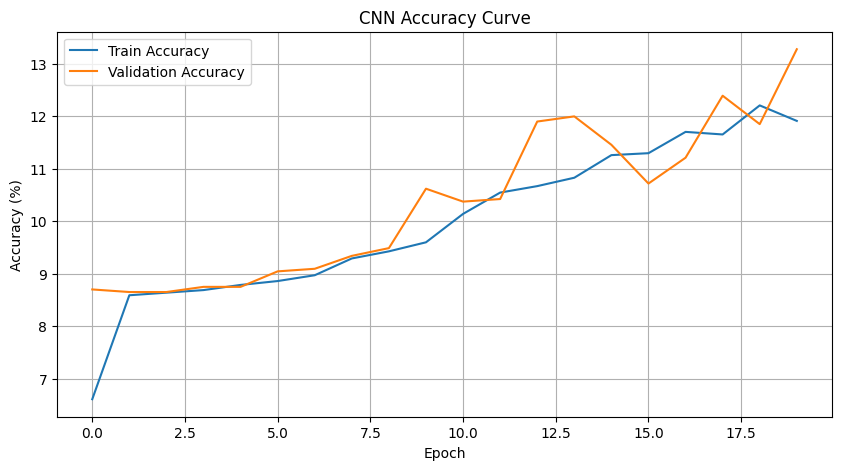

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy Curves
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Test Accuracy
model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()

correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 79.41%
